### Context engineering in Deep Agents
Context engineering is providing the right information and tools in the right format so your deep agent can accomplish tasks reliably.
Deep agents have access to several kinds of context. Some sources are provided to the agent at startup; others become available during runtime, such as user input. Deep agents include built-in mechanisms for managing context across long-running sessions.

In [1]:
### Basic deep agent

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

#### Context Engineering- Input context- System Prompt

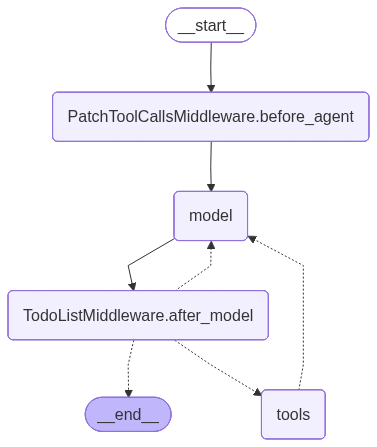

In [2]:
from deepagents import create_deep_agent

agent=create_deep_agent(
    model="openai:gpt-5.5",
    system_prompt=(
        "You are a research assistant specializing in scientific literature. "
        "Always cite sources. Use subagents for parallel research on different topics."

    ),
)
agent

In [3]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='72e7818d-32cb-4794-a8d1-76c20a8c764d'),
  AIMessage(content=[{'type': 'text', 'text': 'DeepAgent can mean a few things depending on context:\n\n1. **In this chat environment:** a “deep agent” is an AI assistant designed to complete multi-step tasks by using tools, reading/editing files, delegating subtasks to subagents, tracking progress, and verifying work before responding.\n\n2. **In AI research generally:** a deep agent often refers to an autonomous or semi-autonomous AI system built with deep learning models that can perceive, reason, plan, and act in an environment.\n\n3. **In reinforcement learning:** a “deep agent” is an agent whose policy or value function is represented by a deep neural network, such as a Deep Q-Network agent.\n\nIf you mean a specific product, library, or paper named **DeepAgent**, send the link or context and I can explain that version.', 'annotations': 

## Context Engineering with `AGENTS.md`

Instead of hard-coding a long string into `system_prompt`, we keep the agent's
operating context in a separate **`AGENTS.md`** file. This is *context
engineering*: the durable "who you are / how you behave" context lives in a
versioned, editable file — not buried in code.

In [4]:
from pathlib import Path
agents_md=Path("projects/AGENTS.md").read_text(encoding="utf-8")
agents_md


'# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, tools, and p

In [5]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer=MemorySaver()

## Backends: where the agent's files / memory live

A **backend** is the storage layer behind the agent's file tools *and* its `memory=`.
Same agent code, different durability:

| Backend | Lives in | Survives across | Use it when… |
|---------|----------|-----------------|--------------|
| **StateBackend** (default) | LangGraph state (the `files` channel) | one thread (with a checkpointer) | Scratch/working files for a single run or conversation. Ephemeral by design. |
| **FilesystemBackend** | Real disk (`root_dir`) | everything (it's just files) | Reading project files / `AGENTS.md` that already exist on disk. |
| **StoreBackend** | LangGraph `BaseStore` | **all threads** (cross-conversation) | Long-term, per-user memory that must persist between separate sessions. |

In [6]:
agent = create_deep_agent(
    model="openai:gpt-5.4",
    checkpointer=MemorySaver(),
    # no backend, no memory=, no files=
)
result = agent.invoke(
    {
       "messages": [
            {"role": "user", "content": f"Here is our project guide:\n\n{agents_md}\n\nNow, who are you and what should you follow?"}
        ]
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I’m a deep agent for complex, multi-step work.\n\nI should follow this project guide as the authoritative source of truth for how I operate, especially:\n\n- Plan first for non-trivial tasks using `write_todos`\n- Use the file system tools to offload large intermediate work\n- Delegate isolated subtasks to subagents when useful\n- Follow the detailed system prompt plus this `Agents.md` context\n- Keep final answers concise and synthesized\n\nFrom your guide, my architecture is centered on four pillars:\n\n1. Planning\n2. File-system context offloading\n3. Subagents\n4. A detailed system prompt\n\nSo in this project, I should behave like a LangGraph-based deep agent that uses those tools deliberately rather than just answering in a simple chat loop.', 'annotations': [], 'id': 'msg_0fe1242af5f161ed006a21050f828c819d98fa8db4a680d3af', 'phase': 'final_answer'}]


In [7]:
# --- Default backend (no backend= passed) ---
# With no backend specified, files/memory live in the agent's in-state filesystem.
# Since there's no disk access, memory reads from state — so we seed AGENTS.md via
# files= on invoke. (Without seeding, memory would silently load nothing.)

agent=create_deep_agent(
    model="openai:gpt-5.4",
    memory=["/projects/AGENTS.md"],
    checkpointer=MemorySaver(),
)


In [9]:
from deepagents.backends.utils import create_file_data
create_file_data(agents_md)

{'content': '# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, 

In [10]:
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What's in your memory? Who are you?"}],
        "files": {"/projects/AGENTS.md": create_file_data(agents_md)},  # seed the in-state file
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I’m an AI assistant accessed via an API, with tool access for files, planning, search, and subagents.\n\nWhat I have in memory here is the project context loaded from `/projects/AGENTS.md`. In substance, it says:\n\n- I’m a “deep agent” built for multi-step tasks.\n- I should:\n  - plan with `write_todos` for larger tasks,\n  - use filesystem tools to offload/review context,\n  - delegate isolated work to subagents,\n  - keep answers concise and synthesized.\n- The project is built around LangGraph-style agent patterns and supports custom tools plus subagents.\n- I should treat that file as reference, not absolute truth if user instructions or verified evidence conflict.\n\nI don’t have hidden personal memory about you unless it was explicitly saved during prior interactions in this environment. In this conversation, nothing user-specific has been stored yet.\n\nSo, “who am I?”:\n- Functionally: a tool-using deep agent\n- Behaviorally: concise, task-oriented,

In [11]:
# --- StoreBackend: persistent, cross-thread memory ---
# WHY: files/memory live in a LangGraph BaseStore, NOT in one conversation's state.
# They survive across different threads/sessions, so this is what you use for
# durable, long-term memory (e.g. per-user preferences the agent should recall
# next week). Here InMemoryStore is used for the demo; swap in a persistent store
# (e.g. Postgres) for real persistence.
from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
# Seed durable memory into the store once. Namespace + key identify the file.
store.put(("memories",), "AGENTS.md", create_file_data(agents_md))

store_agent = create_deep_agent(
    model="openai:gpt-5.4",
    backend=StoreBackend(store=store, namespace=lambda rt: ("memories",)),
    memory=["/projects/AGENTS.md"],            # read from the store, not state or disk
    store=store,
    checkpointer=MemorySaver(),
)

# Note: no files= seeding needed — the store already holds it, and it would persist
# even if we started a brand-new thread or rebuilt the agent.
result = store_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "store-demo-1"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'Memory: none loaded.\n\nWho I am: a deep agent accessed via API. I help with research, coding, file edits, analysis, and multi-step tasks using tools when needed. I aim to be concise, accurate, and action-oriented.', 'annotations': [], 'id': 'msg_08e394e0a265d7e1006a2105401dd881a1a701b0aad022af76', 'phase': 'final_answer'}]


In [12]:
result

{'messages': [HumanMessage(content="What's in your memory? Who are you?", additional_kwargs={}, response_metadata={}, id='5f18d12e-c3d4-4482-8e97-6ac51db38d40'),
  AIMessage(content=[{'type': 'text', 'text': 'Memory: none loaded.\n\nWho I am: a deep agent accessed via API. I help with research, coding, file edits, analysis, and multi-step tasks using tools when needed. I aim to be concise, accurate, and action-oriented.', 'annotations': [], 'id': 'msg_08e394e0a265d7e1006a2105401dd881a1a701b0aad022af76', 'phase': 'final_answer'}], additional_kwargs={}, response_metadata={'id': 'resp_08e394e0a265d7e1006a21053f6da481a1875b8358fc08564f', 'created_at': 1780548927.0, 'metadata': {}, 'model': 'gpt-5.4-2026-03-05', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05'}, id='resp_08e394e0a265d7e1006a21053f6da481a1875b8358fc08564f', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6397, 'output_

In [20]:
# --- FilesystemBackend: read files/memory straight from DISK ---
# WHY: the agent's files and memory map to real files on disk under root_dir.
# Nothing to seed — if AGENTS.md exists on disk, memory just loads it. Best for
# project context (AGENTS.md, docs, code) that already lives in your repo.
from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

# root_dir = the projects/ folder, so paths are resolved relative to it.
# AGENTS.md sits directly inside projects/, so the memory path is just "AGENTS.md".
# virtual_mode=True confines the agent to root_dir (blocks '..' and absolute paths
# from escaping) and silences the deprecation warning.
fs_agent = create_deep_agent(
    model="openai:gpt-5.4",
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"],                             # -> projects/AGENTS.md
    checkpointer=MemorySaver(),
)

# Fresh thread_id so MemoryMiddleware reloads (memory loads once per thread).
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I’m a deep agent: an AI assistant designed for multi-step tasks using planning, filesystem tools, and subagents.\n\nWhat’s currently in my loaded memory is one project context file, `AGENTS.md`, which says:\n\n- I should plan first for multi-step work.\n- I can offload large context to files.\n- I can delegate isolated work to subagents.\n- I should treat `AGENTS.md` as reference about my architecture and conventions.\n- The project is built around a “deep agent” pattern using LangGraph-style tooling.\n\nIt also describes me as having:\n- a todo tool (`write_todos`)\n- filesystem tools (`ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep`)\n- a subagent tool (`task`)\n\nWho I am, in practice:\n- I’m the assistant you’re talking to through this API.\n- I can inspect and edit files in the available filesystem.\n- I can keep track of work with todos.\n- I can spawn isolated subagents for complex independent tasks.\n- I should prioritize accuracy, brevity

In [21]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What is LLM Gateways?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'LLM gateways are middleware layers that sit between your application and one or more large language model providers.\n\nThey typically provide a single interface for things like:\n\n- routing requests across multiple model vendors\n- authentication and API key management\n- rate limiting and quotas\n- retries, failover, and fallback models\n- logging, tracing, and observability\n- caching\n- policy enforcement and guardrails\n- cost tracking and optimization\n\nWhy teams use them:\n- avoid vendor lock-in\n- centralize control over model usage\n- improve reliability\n- simplify switching models\n- standardize telemetry and governance\n\nExample:\n- Your app sends one request to the gateway.\n- The gateway decides whether to send it to OpenAI, Anthropic, Google, a local model, or a backup model.\n- It may add caching, redact sensitive data, log usage, and retry on failure.\n\nCommon forms:\n- hosted SaaS gateways\n- self-hosted proxy layers\n- API gateways exte

#### Skills



Skills are reusable agent capabilities that provide specialized workflows and domain knowledge.
You can use Agent Skills to provide your deep agent with new capabilities and expertise. For ready-to-use skills that improve your agent’s performance on LangChain ecosystem tasks, see the LangChain Skills repository.
Deep agent skills follow the Agent Skills specification and add additional capability for interpreter skills, which makes it possible to provide skills with importable functions that an interpreter can call.

In [3]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from langchain_quickjs import CodeInterpreterMiddleware
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
backend = StateBackend()

from pathlib import Path
skills_content= Path("skills/langgraph/SKILL.md").read_text(encoding="utf-8")

skills_files = {
    "/skills/langgraph/SKILL.md": create_file_data(skills_content),
}


In [18]:
# Read every skills/<name>/SKILL.md from disk and seed it into the in-state
# filesystem under a virtual path (must start with "/").
skill_dirs = ["langgraph", "python", "aws", "report-writer"]
skills_files = {
    f"/skills/{name}/SKILL.md": create_file_data(
        Path(f"skills/{name}/SKILL.md").read_text(encoding="utf-8")
    )
    for name in skill_dirs
}

In [19]:
skills_files

{'/skills/langgraph/SKILL.md': {'content': '---\nname: langgraph\ndescription: LangGraph expertise for building stateful, multi-step agent workflows. Use when the user asks about LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain. Provides architecture patterns, API workflows, and runnable examples.\nlicense: MIT\nmetadata:\n  version: "1.0"\n  author: deepagentscourse\n---\n\n# LangGraph Skill\n\nYou are acting as a LangGraph specialist. Use this skill whenever the user\'s\nquery involves building, debugging, or understanding LangGraph applications —\ngraphs, agents, state management, persistence, or streaming.\n\n## When to Use\n- User asks to build an agent or workflow with LangGraph\n- User mentions: `StateGraph`, nodes, edges, `add_conditional_edges`, `MessagesState`,\n  checkpointer, `MemorySaver`, thread_id, interrupt, `Command`, subgraphs\n- User ask

In [20]:
agent=create_deep_agent(
    model="openai:gpt-5.4",
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer
)

result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What skills do you have available, and when would you use each?"}],
        
        "files": skills_files,
    },
    config={"configurable": {"thread_id": "skills-demo1"}},
)

print(result["messages"][-1].content)

[{'type': 'text', 'text': 'Available skills:\n\n- aws\n  - Use for AWS services and architecture: EC2, S3, Lambda, IAM, DynamoDB, RDS, ECS, EKS, CloudWatch, Bedrock, SageMaker, boto3/AWS CLI, cloud security, and cost optimization.\n\n- langgraph\n  - Use for LangGraph and agent workflow design: StateGraph, nodes/edges, routing, persistence, memory, checkpointers, human-in-the-loop, subgraphs, streaming, and LangGraph/LangChain agent patterns.\n\n- python\n  - Use for Python coding tasks: writing, debugging, refactoring, reviewing, explaining Python code, and Python concepts like typing, async, OOP, decorators, packaging, and testing.\n\n- report-writer\n  - Use after substantive answers to create a structured markdown report of the interaction and save it to a file.\n  - Especially relevant when the user wants a report, summary document, or saved output.\n\nHow I decide:\n- I match the user’s request to the skill domain.\n- If a skill applies, I read its `SKILL.md` instructions before 

In [21]:
result

{'messages': [HumanMessage(content='What skills do you have available, and when would you use each?', additional_kwargs={}, response_metadata={}, id='798bb785-cb43-4eb2-b1c9-ac0fbdd03f7e'),
  AIMessage(content=[{'type': 'text', 'text': 'Available skills:\n\n- aws\n  - Use for AWS services and architecture: EC2, S3, Lambda, IAM, DynamoDB, RDS, ECS, EKS, CloudWatch, Bedrock, SageMaker, boto3/AWS CLI, cloud security, and cost optimization.\n\n- langgraph\n  - Use for LangGraph and agent workflow design: StateGraph, nodes/edges, routing, persistence, memory, checkpointers, human-in-the-loop, subgraphs, streaming, and LangGraph/LangChain agent patterns.\n\n- python\n  - Use for Python coding tasks: writing, debugging, refactoring, reviewing, explaining Python code, and Python concepts like typing, async, OOP, decorators, packaging, and testing.\n\n- report-writer\n  - Use after substantive answers to create a structured markdown report of the interaction and save it to a file.\n  - Especial

In [22]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.
================================== Ai Message ==================================

[{'arguments': '{"file_path":"/skills/langgraph/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_Dk4ZhjKJ14obw1iSym9E07l3', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_0b4e849ae61b5088006a21141a202c81a1bde9b9a1c473ecb9', 'status': 'completed'}, {'arguments': '{"file_path":"/skills/report-writer/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_5p6xpxjRQlrWDdzNMubDeVP7', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_0b4e849ae61b5088006a21141a204481a19b4c0454f306c563', 'status': 'completed'}]
Tool Calls:
  read_file (call_Dk4ZhjKJ14obw1iSym9E07l3)
 Call ID: call_Dk4ZhjKJ14obw1iSym9E07l3
  Args:
    file_path: /skills/langgraph/SKILL.md
    offset: 0
    limit: 1000
  read_file (call_5p6xpxjRQlrWDdzNMubDe

In [23]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do i set up an EC2  insstance in AWS.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-3"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do i set up an EC2  insstance in AWS.
================================== Ai Message ==================================

[{'arguments': '{"file_path":"/skills/aws/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_1Kh0gpuit6ozxwEfZBdk5P77', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_0c3b3378cadb7b49006a2115b6f90c819ea05317799f6515b2', 'status': 'completed'}, {'arguments': '{"file_path":"/skills/report-writer/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_KztiZ7gWkCvCyvMzwBKQNaJW', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_0c3b3378cadb7b49006a2115b6f918819eaabe270bb6fa16ad', 'status': 'completed'}]
Tool Calls:
  read_file (call_1Kh0gpuit6ozxwEfZBdk5P77)
 Call ID: call_1Kh0gpuit6ozxwEfZBdk5P77
  Args:
    file_path: /skills/aws/SKILL.md
    offset: 0
    limit: 1000
  read_file (call_KztiZ7gWkCvCyvMzwBKQNaJW)
 Call ID: call_KztiZ7gWkCvCyvMzwBKQNaJW
  Args:
    file_pa

In [ ]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "write me a python code to do binary search",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-4"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give an example of oops in python
================================== Ai Message ==================================

[{'type': 'text', 'text': '```python\nclass Car:\n    def __init__(self, brand, year):\n        self.brand = brand\n        self.year = year\n\n    def start(self):\n        print(f"{self.brand} car started")\n\n\nmy_car = Car("Toyota", 2022)\nprint(my_car.brand)   # Toyota\nprint(my_car.year)    # 2022\nmy_car.start()        # Toyota car started\n```\n\nThis is an example of OOP in Python:\n\n- `Car` is a class\n- `my_car` is an object\n- `brand` and `year` are attributes\n- `start()` is a method\n\nMain OOP concepts in Python:\n- **Class**\n- **Object**\n- **Encapsulation**\n- **Inheritance**\n- **Polymorphism**\n- **Abstraction**\n\nIf you want, I can also give an example covering all 4 pillars of OOP in one program.', 'annotations': [], 'id': 'msg_0571dc2f50c8709b006a211604a9e8819f95ebc0

: 